# Laboratorio 4: Regresión Logística Binaria
**Estudiante:** Diego Leytao Espinoza Virgo
**Dataset:** Body Signal of Smoking (Señales corporales de tabaquismo)

In [ ]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar el dataset con Pandas 
df = pd.read_csv('smoking.csv')

# Eliminar la columna ID porque es solo un correlativo y no aporta información predictiva
df = df.drop('ID', axis=1)

# Convertir variables de texto ('gender', 'oral', 'tartar') a valores numéricos (0 y 1)
# drop_first=True evita variables redundantes (ej. convierte F/M en una sola columna numérica)
df = pd.get_dummies(df, columns=['gender', 'oral', 'tartar'], drop_first=True)

# Convertir explícitamente todo a float (números decimales) para que NumPy no dé errores
df = df.astype(float)

# 2. Separar características (X) y variable objetivo (y)
X_pandas = df.drop('smoking', axis=1)
y_pandas = df['smoking']

# Convertir a arreglos de NumPy para facilitar los cálculos matemáticos
X = X_pandas.values
y = y_pandas.values

# 3. División del Dataset: 80% Entrenamiento y 20% Prueba
m = len(y)
train_size = int(m * 0.8)

# Desordenar los datos aleatoriamente para evitar sesgos antes de cortar
np.random.seed(42) # Fijamos una semilla para que el resultado sea reproducible
indices = np.random.permutation(m)
X_shuffled = X[indices]
y_shuffled = y[indices]

# Corte 80/20
X_train = X_shuffled[:train_size]
y_train = y_shuffled[:train_size]
X_test = X_shuffled[train_size:]
y_test = y_shuffled[train_size:]

# 4. Función para normalizar características
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    # Evitar división por cero en columnas constantes
    sigma[sigma == 0] = 1 
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# Normalizamos los datos de entrenamiento
X_train_norm, mu, sigma = featureNormalize(X_train)
# Normalizamos los datos de prueba usando mu y sigma del entrenamiento
X_test_norm = (X_test - mu) / sigma

# Agregar la columna de unos (término de intercepción theta_0)
X_train_norm = np.concatenate([np.ones((X_train_norm.shape[0], 1)), X_train_norm], axis=1)
X_test_norm = np.concatenate([np.ones((X_test_norm.shape[0], 1)), X_test_norm], axis=1)

print("Datos de entrenamiento listos. Forma de X_train:", X_train_norm.shape)
print("Datos de prueba listos. Forma de X_test:", X_test_norm.shape)

Datos de entrenamiento listos. Forma de X_train: (44553, 25)
Datos de prueba listos. Forma de X_test: (11139, 25)


## 2. Definición del Modelo Matemático
Implementamos tres funciones matemáticas fundamentales utilizando NumPy puro:

In [2]:
# 1. Función Sigmoide
def sigmoid(z):
    # Usamos np.clip para evitar desbordamientos matemáticos (overflow) con números muy grandes
    z = np.clip(z, -250, 250)
    return 1.0 / (1.0 + np.exp(-z))

# 2. Función de Costo
def calcularCosto(theta, X, y):
    m = len(y)
    h = sigmoid(np.dot(X, theta))
    
    # Añadimos un valor minúsculo (epsilon) para evitar el error matemático de log(0)
    epsilon = 1e-5 
    J = -(1 / m) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
    return J

# 3. Descenso por el Gradiente
def descensoGradiente(theta, X, y, alpha, num_iters):
    m = len(y)
    theta = theta.copy()
    J_history = [] # Aquí guardaremos el costo en cada iteración para la gráfica

    for i in range(num_iters):
        # Calcular la hipótesis
        h = sigmoid(np.dot(X, theta))
        
        # Actualizar los parámetros theta usando la derivada (gradiente)
        theta = theta - (alpha / m) * np.dot(X.T, (h - y))
        
        # Guardar el costo actual
        J_history.append(calcularCosto(theta, X, y))
        
    return theta, J_history

Iniciando el entrenamiento del modelo...
¡Entrenamiento finalizado!


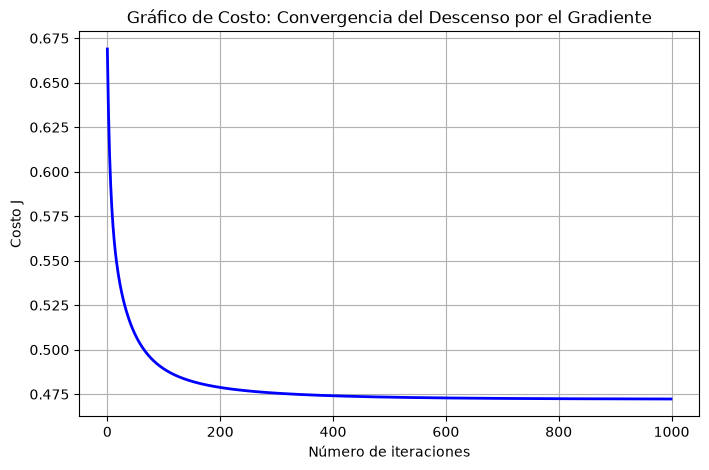

In [3]:
# Inicializar los parámetros theta con ceros
# X_train_norm.shape[1] nos da el número total de columnas (25)
n = X_train_norm.shape[1]
theta_inicial = np.zeros(n)

# Configurar los hiperparámetros de entrenamiento
alpha = 0.1      # Tasa de aprendizaje
num_iters = 1000 # Número de iteraciones

print("Iniciando el entrenamiento del modelo...")
theta_optimo, J_history = descensoGradiente(theta_inicial, X_train_norm, y_train, alpha, num_iters)
print("¡Entrenamiento finalizado!")

# Generar el gráfico de convergencia del costo
plt.figure(figsize=(8, 5))
plt.plot(np.arange(len(J_history)), J_history, lw=2, color='blue')
plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J')
plt.title('Gráfico de Costo: Convergencia del Descenso por el Gradiente')
plt.grid(True)
plt.show()

## 3. Validación y Predicciones
Una vez que hemos encontrado los parámetros óptimos (`theta_optimo`), validamos el modelo utilizando el **20% de los datos de prueba** que separamos al inicio. 

Para demostrar la efectividad del modelo de clasificación binaria, calculamos la probabilidad con la función sigmoide. Si la probabilidad es mayor o igual a 0.5, predecimos que el paciente es fumador (1); de lo contrario, predecimos que no es fumador (0). Finalmente, comparamos estas predicciones con los valores reales para obtener el porcentaje de precisión.

In [4]:
# 1. Definir la función de predicción
def predecir(theta, X):
    # Calculamos la probabilidad
    probabilidad = sigmoid(np.dot(X, theta))
    # Retornamos 1 si la probabilidad es >= 0.5, sino 0
    return np.where(probabilidad >= 0.5, 1, 0)

# 2. Realizar las predicciones con el 20% de datos de prueba
print("Realizando predicciones con los datos de prueba...")
predicciones = predecir(theta_optimo, X_test_norm)

# 3. Calcular la efectividad (precisión)
precision = np.mean(predicciones == y_test) * 100

print(f"¡La precisión del modelo en los datos de prueba es: {precision:.2f}%!")

Realizando predicciones con los datos de prueba...
¡La precisión del modelo en los datos de prueba es: 73.99%!
